# 02. The volatility forecasts

Six models, one question each day: how volatile will tomorrow be? They range from a
plain rolling average to the GARCH family to a Random Forest. Every one uses only past
data, and every one is scored the same way.

The forecasts are cached in `data/processed/forecasts.csv` so this notebook is quick.
The commented lines show how to rebuild them from scratch, which takes a couple of
minutes because the GARCH models are refit again and again through time.

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.evaluation import accuracy_table, dm_matrix

# To rebuild instead of loading the cache:
# from src.data_loader import load_ohlc
# from src.features import build_feature_table
# from src.forecasts import build_forecasts
# feat = build_feature_table(load_ohlc("../data/raw/spy.csv"))
# fc = build_forecasts(feat, scale_k=1.1692)

ANN = np.sqrt(252)
MODELS = ["rolling", "ewma", "garch", "gjr", "egarch", "rf"]
fc = pd.read_csv("../data/processed/forecasts.csv", index_col=0, parse_dates=True)
print("evaluation sample:", fc.index.min().date(), "to", fc.index.max().date(), "|", len(fc), "days")

evaluation sample: 2008-01-28 to 2026-03-17 | 4563 days


## How accurate is each one

We score each forecast against realised volatility with three losses. QLIKE is the one
to watch: it handles the noisy target well and it punishes under prediction harder,
which is what matters when you are sizing risk. Lower is better.

In [2]:
acc = accuracy_table(fc["realized"], fc[MODELS])
acc.round(5)

,MSE,MAE,QLIKE
gjr,0.00003,0.00343,0.38834
egarch,0.00002,0.00336,0.40426
garch,0.00003,0.00361,0.41249
rf,0.00003,0.00321,0.44828
ewma,0.00003,0.00384,0.45642
rolling,0.00004,0.00390,0.51078


GJR-GARCH has the lowest QLIKE, with EGARCH and plain GARCH close behind. The Random
Forest and EWMA sit in the middle, and the simple rolling window is clearly last. The
models that let a drop raise volatility more than a rise (GJR and EGARCH) do best,
which is the well known leverage effect in equities.

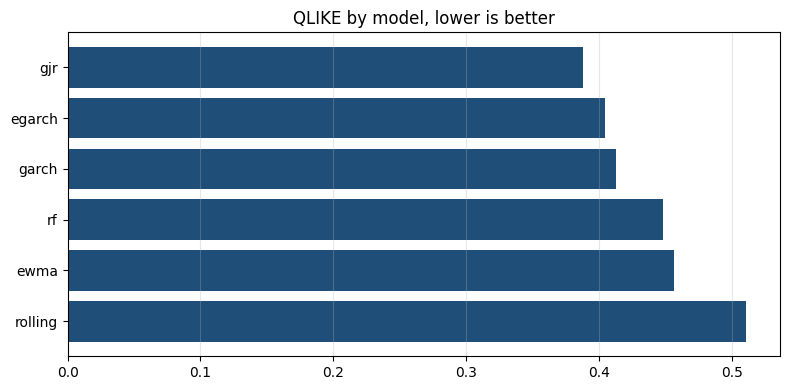

In [3]:
# Same story as a bar chart.
fig, ax = plt.subplots(figsize=(8, 4))
order = acc["QLIKE"].sort_values(ascending=False)
ax.barh(order.index, order.values, color="#1f4e79")
ax.set_title("QLIKE by model, lower is better"); ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

## Is the gap real, or luck?

A smaller number is not always a meaningful difference. The Diebold-Mariano test checks
that. Each cell is a p value for whether two forecasts really differ in accuracy; small
means yes.

In [4]:
dm_matrix(fc["realized"], fc[MODELS])

,rolling,ewma,garch,gjr,egarch,rf
rolling,NaN,0.000,0.0000,0.0000,0.0000,0.0000
ewma,0.0,NaN,0.0000,0.0000,0.0000,0.4770
garch,0.0,0.000,NaN,0.0000,0.2361,0.0084
gjr,0.0,0.000,0.0000,NaN,0.0006,0.0003
egarch,0.0,0.000,0.2361,0.0006,NaN,0.0052
rf,0.0,0.477,0.0084,0.0003,0.0052,NaN


GJR-GARCH is significantly more accurate than everything else. GARCH and EGARCH are a
statistical tie with each other, as are EWMA and the Random Forest. Rolling is
significantly the worst. So the ranking above is not an accident of these particular
years.

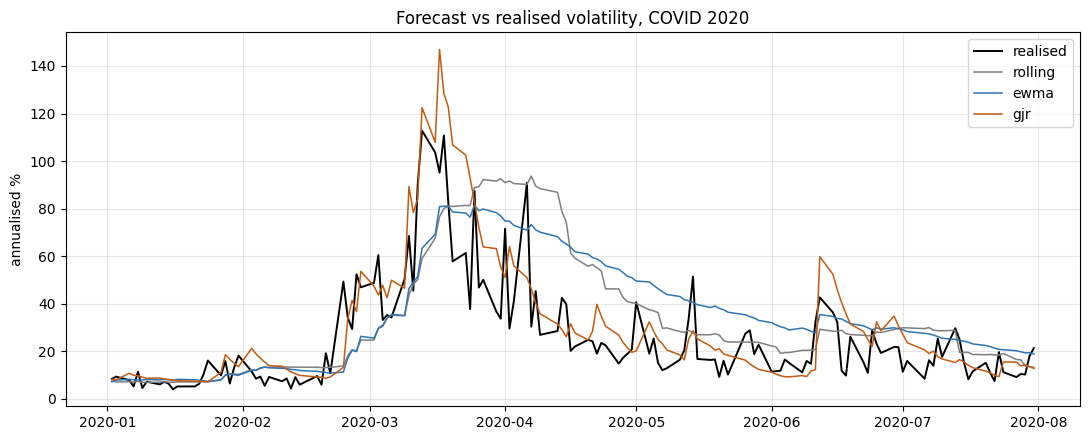

In [5]:
# Watch the forecasts react to the COVID crash. The rolling window lags badly because
# a moving average only lifts once the big days are already inside its window.
fig, ax = plt.subplots(figsize=(11, 4.5))
win = fc.loc["2020-01-01":"2020-07-31"]
ax.plot(win.index, win["realized"] * ANN * 100, color="black", lw=1.4, label="realised")
for m, c in [("rolling", "#7f7f7f"), ("ewma", "#2e75b6"), ("gjr", "#c55a11")]:
    ax.plot(win.index, win[m] * ANN * 100, lw=1.1, label=m, color=c)
ax.set_title("Forecast vs realised volatility, COVID 2020"); ax.set_ylabel("annualised %")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

That lag is the whole story of the accuracy numbers. GARCH turns fast, rolling turns
slow, and in a crisis the difference is large.